Goal of this notebook is to produce a list baseflow of the same lenght as the assumed flows list below  
Assumed hydrograph for now - .out files can be obtained later   
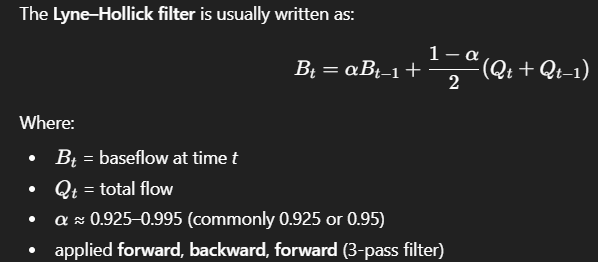

In [2]:
# Initial assumed hydrographs and alpha
flows = [2.1, 2.3, 3.8, 7.2, 12.5, 9.1, 6.0, 4.2, 3.1, 2.5]
alpha = 0.925

In [25]:
# Defining Lynne Hollick filter function 
def lynne_hollick_pass(flows, alpha):

    # Initialise baseflow list
    baseflow = []
    baseflow.append(flows[0])
    
    # For loop to iterate through the flow values 
    for i in range(1,len(flows)):
    
        previous_bf = baseflow[i - 1]
        previous_flow = flows[i - 1]
        current_flow = flows[i]

        bf = alpha * previous_bf + (1 - alpha)/2 * (current_flow + previous_flow)

        if bf > current_flow:
            bf = current_flow

        baseflow.append(bf)

    return baseflow


bf_forward = lynne_hollick_pass(flows,alpha)
print(bf_forward)

[2.1, 2.1075, 2.1781875, 2.4273234374999997, 2.9840241796874993, 3.5702223662109365, 3.868705688745116, 3.961052762089232, 3.1, 2.5]


In [ ]:
# Implementing backward pass 
def lynne_hollick(flows,alpha):

    #Forward pass 1
    bf1 = lynne_hollick_pass(flows,alpha)
    
    #Backward pass 1
    bf2 = lynne_hollick_pass(bf1[::-1],alpha)[::-1]

    #Forward pass 2
    bf3 = lynne_hollick_pass(bf2,alpha)

    return bf3



    